In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

## Part 1(a)


In [ ]:
# Data
part1a = pd.read_csv('data/ml-latest-small/movies.csv')

# Year column
part1a['year'] = part1a['title'].str.extract(r'\((\d{4})\)')
part1a['year'] = pd.to_numeric(part1a['year'], errors='coerce')

# 5 year blocks
part1a['year_block'] = (part1a['year'] // 10 * 10).astype('Int64')
part1a['year_block_label'] = part1a['year_block'].apply(lambda x: f"{int(x)}-{int(x+9)}" if pd.notna(x) else None)

# Split genres and expand
part1a = part1a.assign(genre=part1a['genres'].str.split('|')).explode('genre')
part1a = part1a.dropna(subset=['year_block', 'genre'])

# Group by year block and genre
part1a_groupby = part1a.groupby(['year_block_label', 'genre']).size().reset_index(name='count')
part1a_pivot = part1a_groupby.pivot(index='genre', columns='year_block_label', values='count').fillna(0)

# Sort columns chronologically
part1a_pivot = part1a_pivot.reindex(sorted(part1a_pivot.columns, key=lambda x: int(x.split('-')[0])), axis=1)

part1a_pivot.head(10)

year_block_label,1900-1909,1910-1919,1920-1929,1930-1939,1940-1949,1950-1959,1960-1969,1970-1979,1980-1989,1990-1999,2000-2009,2010-2019
genre,,,,,,,,,,,,
(no genres listed),0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0,0.0,16.0
Action,1.0,1.0,3.0,8.0,8.0,15.0,56.0,103.0,227.0,392.0,549.0,464.0
Adventure,1.0,1.0,5.0,13.0,13.0,30.0,65.0,71.0,170.0,239.0,363.0,292.0
Animation,1.0,0.0,1.0,5.0,8.0,7.0,24.0,26.0,63.0,100.0,204.0,172.0
Children,0.0,0.0,1.0,10.0,12.0,13.0,40.0,38.0,69.0,183.0,190.0,108.0
Comedy,1.0,3.0,15.0,53.0,55.0,67.0,132.0,155.0,492.0,890.0,1135.0,758.0
Crime,1.0,0.0,2.0,15.0,29.0,29.0,43.0,70.0,124.0,264.0,404.0,218.0
Documentary,0.0,0.0,1.0,2.0,1.0,1.0,8.0,11.0,26.0,73.0,198.0,119.0
Drama,0.0,3.0,16.0,74.0,118.0,146.0,192.0,225.0,439.0,1038.0,1365.0,743.0


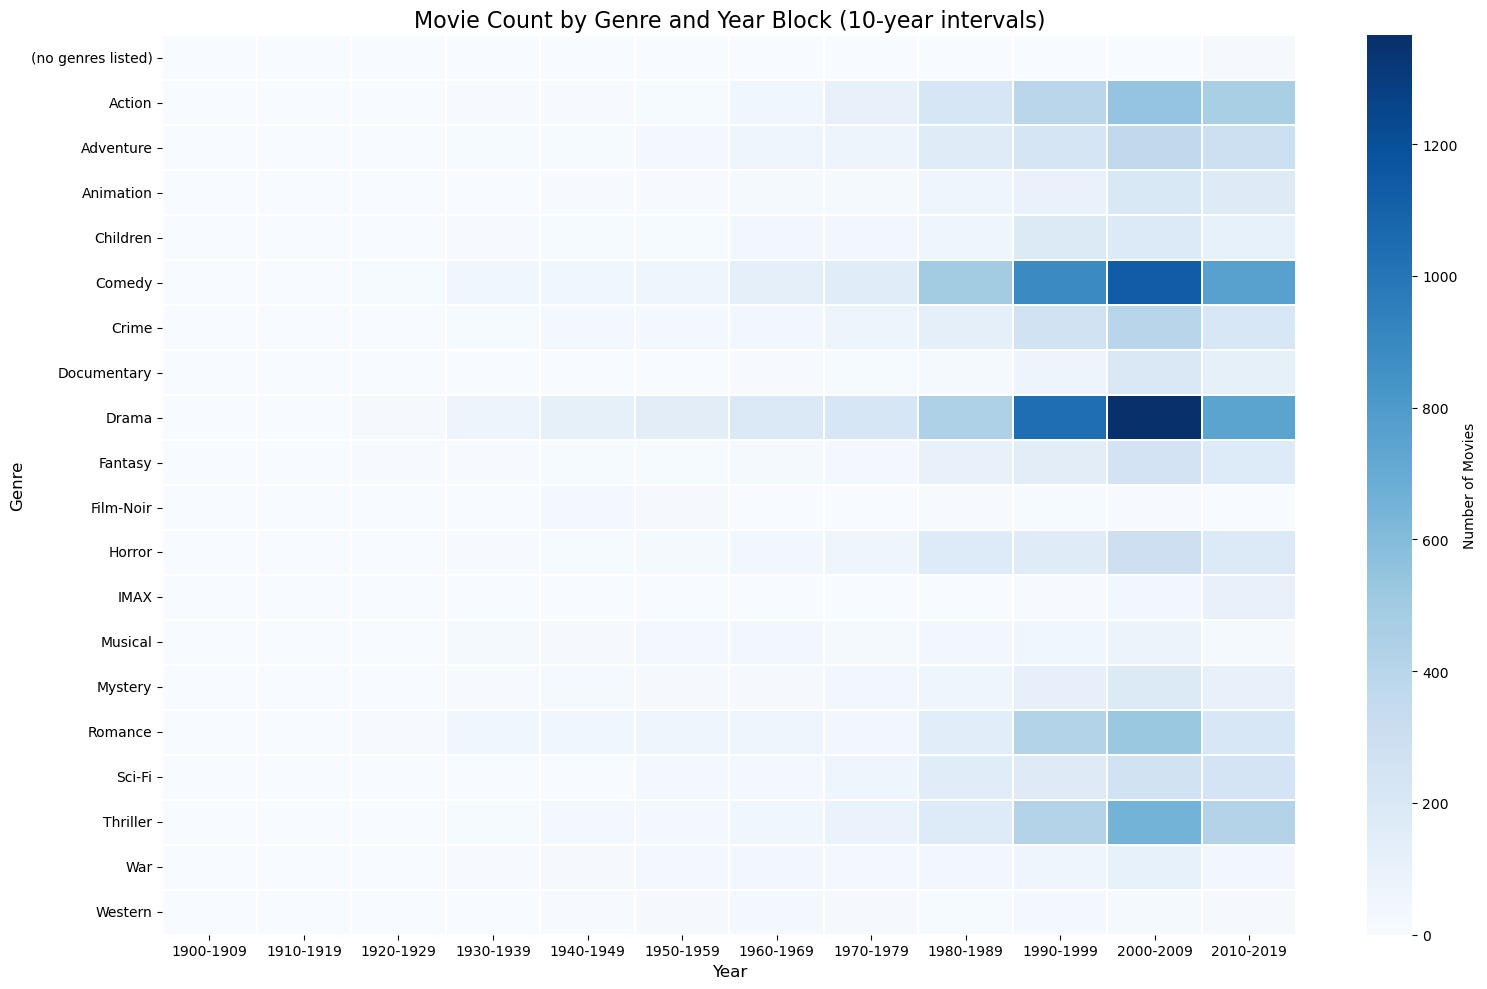

In [ ]:
plt.figure(figsize=(16,10))
sns.heatmap(part1a_pivot, cmap='Blues', cbar_kws={'label': 'Number of Movies'}, linewidths=0.1)
plt.title('Movie Count by Genre and Year Block (10-year intervals)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

## Part 1(b)


In [ ]:
# Reviews
reviews = pd.read_csv('data/ml-latest-small/ratings.csv')[['movieId', 'rating']]

#Join
part1b = part1a.merge(reviews, on='movieId', how='left')

part1b.head()

,movieId,title,genres,year,year_block,year_block_label,genre,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.0
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.5
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,2.5
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.5


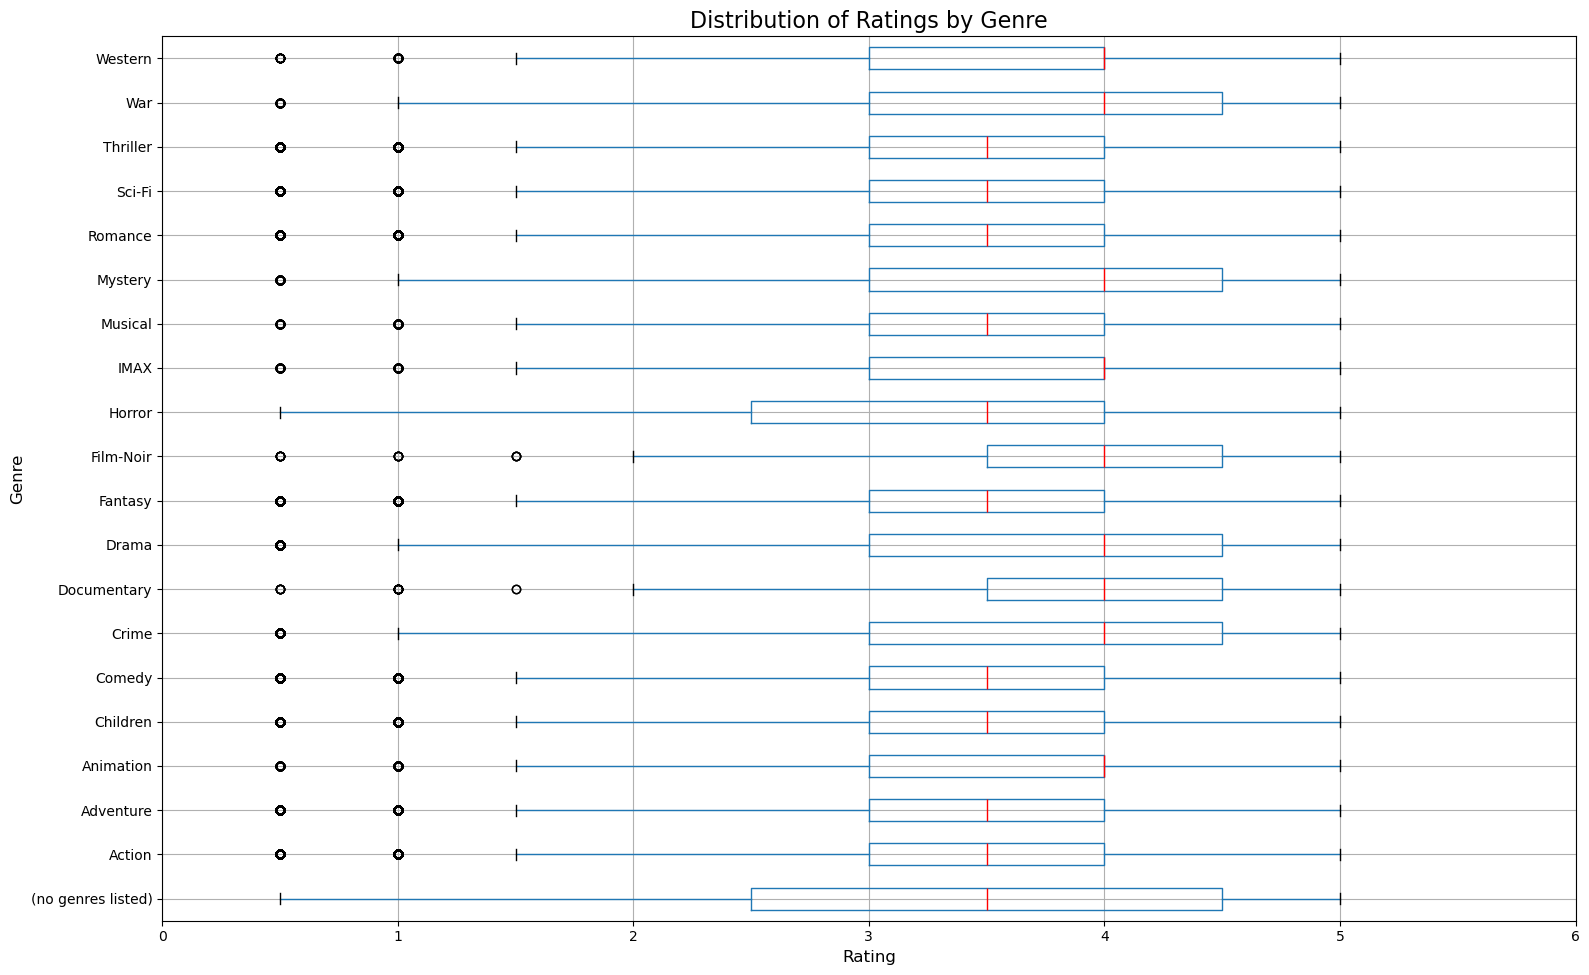

In [ ]:
part1b.boxplot(column='rating', by='genre', figsize=(16,10), vert=False, medianprops=dict[str, str](color='red'))
plt.ylabel('Genre', fontsize=12)
plt.xlabel('Rating', fontsize=12)
plt.title('Distribution of Ratings by Genre', fontsize=16)
plt.xlim(0, 6)
plt.suptitle('')
plt.tight_layout()
plt.show()

## Part 2


In [48]:
df = pd.read_csv('data/daily_show_guests.csv')

df.head(5)

,YEAR,GoogleKnowlege_Occupation,Show,Group,Raw_Guest_List
0,1999,actor,1/11/99,Acting,Michael J. Fox
1,1999,Comedian,1/12/99,Comedy,Sandra Bernhard
2,1999,television actress,1/13/99,Acting,Tracey Ullman
3,1999,film actress,1/14/99,Acting,Gillian Anderson
4,1999,actor,1/18/99,Acting,David Alan Grier


In [50]:
def set_category(x):
    if x == 'Acting' or x == 'Comedy' or x == 'Musician':
        return 'Acting, Comedy, & Music'
    elif x == 'Media':
        return 'Media'
    elif x == 'Government' or x == 'Politician' or x == 'Political Aide':
        return 'Government and Politics'
    else:
        return ''
    

df['category'] = df['Group'].apply(set_category)

df = df[df['category'] != '']

df[['category', 'Group']].head(5)

,category,Group
0,"Acting, Comedy, & Music",Acting
1,"Acting, Comedy, & Music",Comedy
2,"Acting, Comedy, & Music",Acting
3,"Acting, Comedy, & Music",Acting
4,"Acting, Comedy, & Music",Acting


In [51]:
fix_df = df.groupby(['YEAR', 'category']).size().reset_index(name='Count')


fix_df['proportion'] = (fix_df['Count'] / fix_df.groupby('YEAR')['Count'].transform('sum')) * 100
fix_df.head(5)

,YEAR,category,Count,proportion
0,1999,"Acting, Comedy, & Music",150,92.024540
1,1999,Government and Politics,2,1.226994
2,1999,Media,11,6.748466
3,2000,"Acting, Comedy, & Music",125,78.125000
4,2000,Government and Politics,14,8.750000


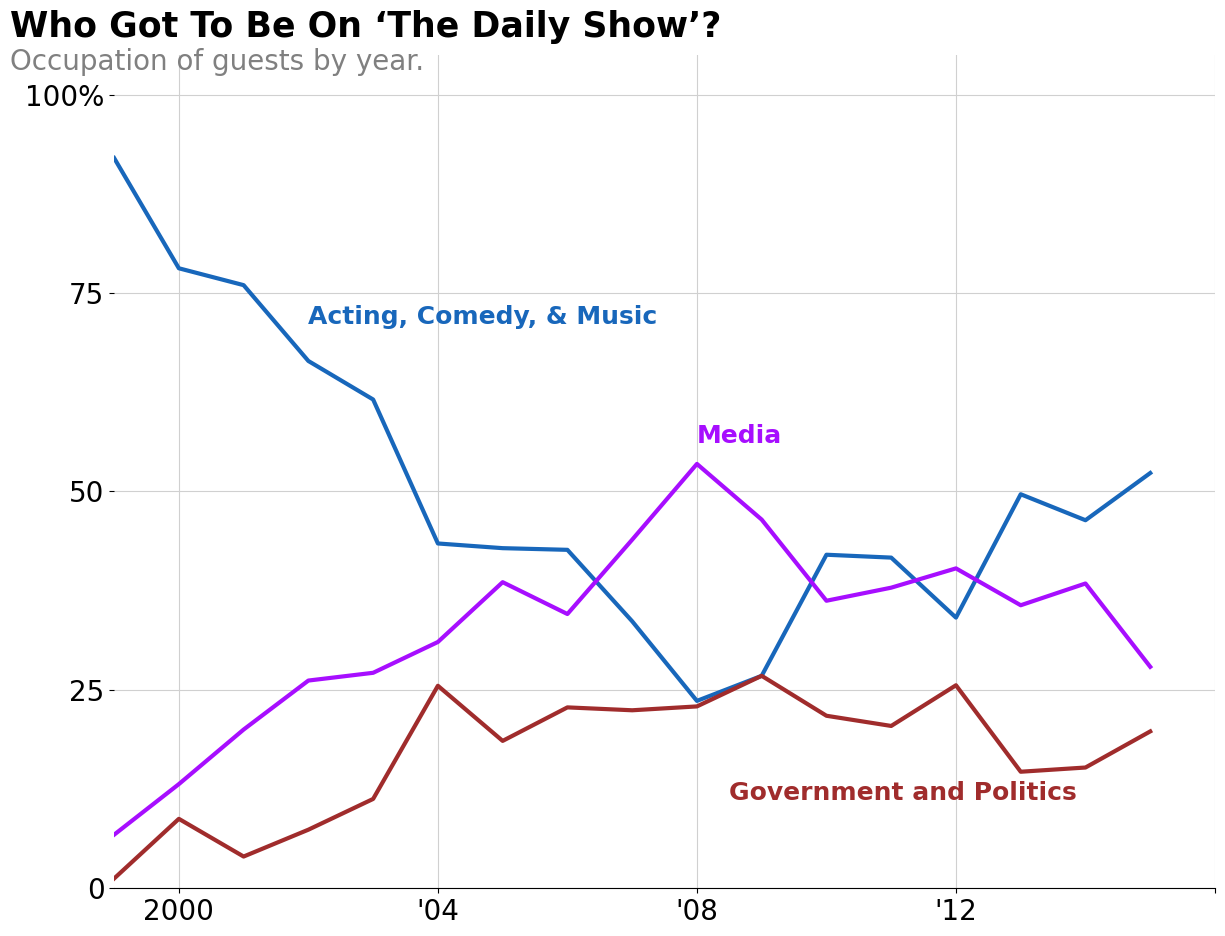

In [53]:

color_map = {
    'Acting, Comedy, & Music': "#1867bb",
    'Media': "#a70eff",
    'Government and Politics': "#a02c2c"
}

txt_placement = {
    'Acting, Comedy, & Music': [2002, 72],
    'Media': [2008, 57],
    'Government and Politics': [2008.5, 12]
    }


year = [2000, 2004, 2008, 2012, 2016]

percentage = [0, 25, 50, 75, 100]

fig, ax = plt.subplots(figsize=(12.2, 9.5))

ax.set_xlim(fix_df['YEAR'].min(), 2012)
ax.set_ylim(0, 105)

fig.suptitle(
    "Who Got To Be On ‘The Daily Show’?",
    fontsize=25,
    fontweight='bold',
    x=0,
    ha='left'
)

fig.text(0, 0.94, "Occupation of guests by year.", ha='left', va='top', fontsize=20, color='gray')



plt.xticks(ticks=year, labels=[2000, "'04", "'08", "'12", ''])

plt.yticks(ticks=percentage, labels = [0, 25, 50, 75, '100%'])

ax.tick_params(axis='both', labelsize=20)
for category, g in fix_df.groupby('category'):
    g = g.sort_values('YEAR')

    ax.plot(
        g['YEAR'],
        g['proportion'],
        color=color_map.get(category, 'gray'),
        linewidth=3
    )

    x_last = txt_placement[category][0]
    y_last = txt_placement[category][1]

    ax.text(
        x_last,
        y_last,
        category,
        color=color_map.get(category, 'black'),
        fontsize=18,
        fontweight='bold',
        va='center'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', color='#d0d0d0')
ax.set_ylabel('')

ax.grid(axis='y', color='#d0d0d0') 
ax.grid(axis='x', color='#d0d0d0')

    

plt.tight_layout()
plt.show()


## Part 3


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

In [5]:
df = pd.read_csv("data/my_basket.csv")

print(df.shape)
df.head()

(2000, 42)


,7up,lasagna,pepsi,yop,red.wine,cheese,bbq,bulmers,mayonnaise,horlics,...,instant.coffee,twix,potatoes,fosters,soup,toad.in.hole,coco.pops,kitkat,broccoli,cigarettes
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,0,0,0,2,1,0,0,0,0,0,...,0,2,0,1,0,0,0,1,0,1
4,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


## Part 3(a)

In [20]:
scaling_summary = pd.DataFrame({
    "min": df.min(),
    "max": df.max(),
    "range": df.max() - df.min(),
    "variance": df.var()
}).sort_values("variance", ascending=False)

scaling_summary.head(10), scaling_summary.describe()


(          min  max  range  variance
 coke        0    7      7  0.605496
 pizza       0    7      7  0.519954
 potatoes    0    5      5  0.443762
 mars        0    5      5  0.410053
 lasagna     0    4      4  0.404993
 bulmers     0    7      7  0.391393
 kitkat      0    4      4  0.380666
 cheese      0    4      4  0.365751
 milk        0    4      4  0.352926
 twix        0    4      4  0.350891,
         min        max      range   variance
 count  42.0  42.000000  42.000000  42.000000
 mean    0.0   3.595238   3.595238   0.212027
 std     0.0   1.288969   1.288969   0.144299
 min     0.0   2.000000   2.000000   0.035327
 25%     0.0   3.000000   3.000000   0.079639
 50%     0.0   3.000000   3.000000   0.173562
 75%     0.0   4.000000   4.000000   0.318877
 max     0.0   7.000000   7.000000   0.605496)

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

pca = PCA(n_components=10, random_state=0)
Z = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f"PC1: {evr[0]*100:.2f}%")
print(f"PC2: {evr[1]*100:.2f}%")
print(f"PC1+PC2: {evr[:2].sum()*100:.2f}%")


PC1: 5.46%
PC2: 5.17%
PC1+PC2: 10.63%


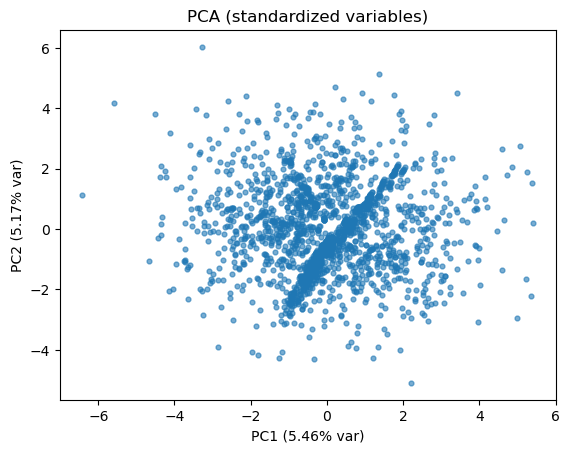

In [22]:
plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=12, alpha=0.6)
plt.xlabel(f"PC1 ({evr[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({evr[1]*100:.2f}% var)")
plt.title("PCA (standardized variables)")
plt.show()


The PCA plot has a dense central cloud with a diagonal structure, indicating some underlying purchasing patterns but no strong separation between groups.

Rescaling was needed because PCA depends on variance, and standardizing prevents frequently purchased items from dominating the components.

The first two principal components explain about 10.6% of the total variance (PC1 ~= 5.46%, PC2 ~= 5.17%), so the 2D plot captures only a small portion of the overall structure in the data.

## Part 3(b)

In [23]:
Z_link_ward = linkage(X_scaled, method="ward", metric="euclidean")
hc_ward = fcluster(Z_link_ward, t=3, criterion="maxclust")

pd.Series(hc_ward).value_counts().sort_index()


1     267
2     276
3    1457
Name: count, dtype: int64

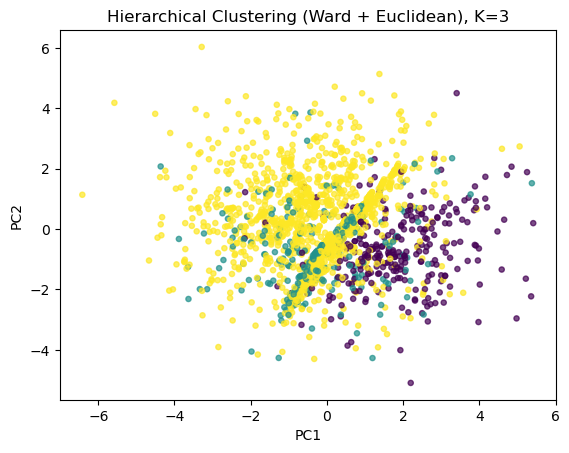

In [24]:
plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=hc_ward, s=14, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering (Ward + Euclidean), K=3")
plt.show()


The hierarchical clustering shows one large diffuse cluster (yellow) and a more compact cluster on the right (purple).
Separation along PC1 is somewhat visible, but there is still noticeable overlap, so clustering only looks partially reasonable in the 2D PCA view. This is expected since PC1-PC2 capture limited variance.

## Part 3(c)

In [25]:
X_bin = (df.values > 0).astype(int)

D_jacc = pdist(X_bin, metric="jaccard")
Z_link_jacc = linkage(D_jacc, method="average")
hc_jacc = fcluster(Z_link_jacc, t=3, criterion="maxclust")

pd.Series(hc_jacc).value_counts().sort_index()


1       5
2     765
3    1230
Name: count, dtype: int64

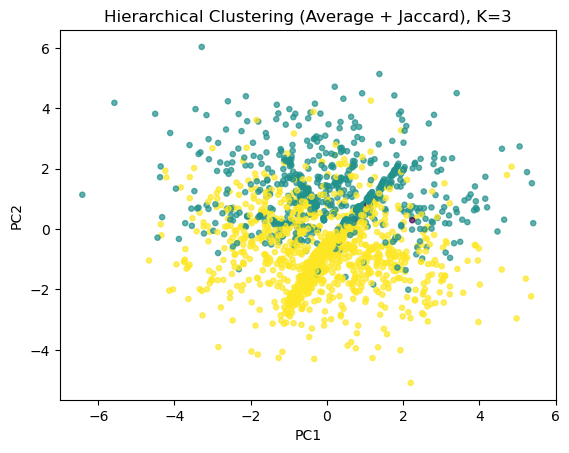

In [26]:
plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=hc_jacc, s=14, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering (Average + Jaccard), K=3")
plt.show()


Using Jaccard distance results in more mixed clusters because it considers only item presence and ignores purchase counts.
Cosine distance produces clusters more similar to Ward, with clearer separation along PC1.
Overall, Jaccard shows more overlap while cosine preserves structure seen in PCA.

In [27]:
D_cos = pdist(X_scaled, metric="cosine")
Z_link_cos = linkage(D_cos, method="average")
hc_cos = fcluster(Z_link_cos, t=3, criterion="maxclust")

pd.Series(hc_cos).value_counts().sort_index()


1     260
2     278
3    1462
Name: count, dtype: int64

## Part 3(d)

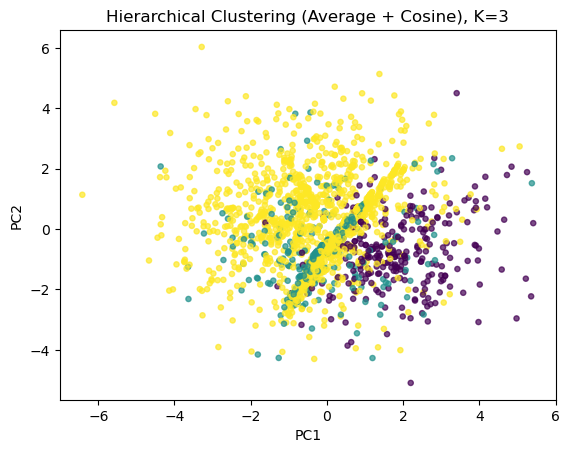

In [28]:
plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=hc_cos, s=14, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering (Average + Cosine), K=3")
plt.show()


In [29]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=0, algorithm="elkan")
km = kmeans.fit_predict(X_scaled)

pd.Series(km).value_counts().sort_index()


0     359
1    1290
2     351
Name: count, dtype: int64

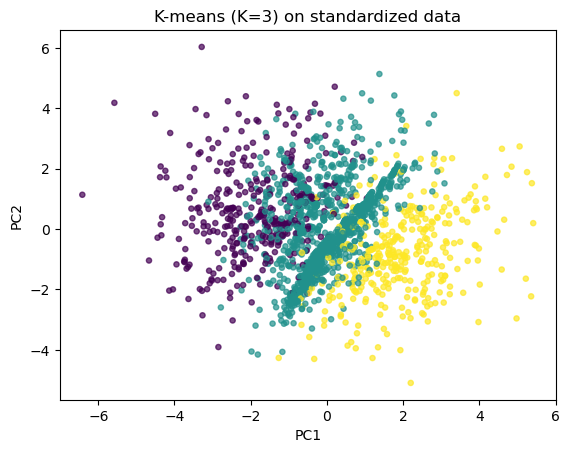

In [30]:
plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=km, s=14, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means (K=3) on standardized data")
plt.show()


K-means produces more balanced clusters with clearer separation along PC1 compared to hierarchical clustering.
Clusters appear more symmetric and compact in PCA space.

## Part 3(e)

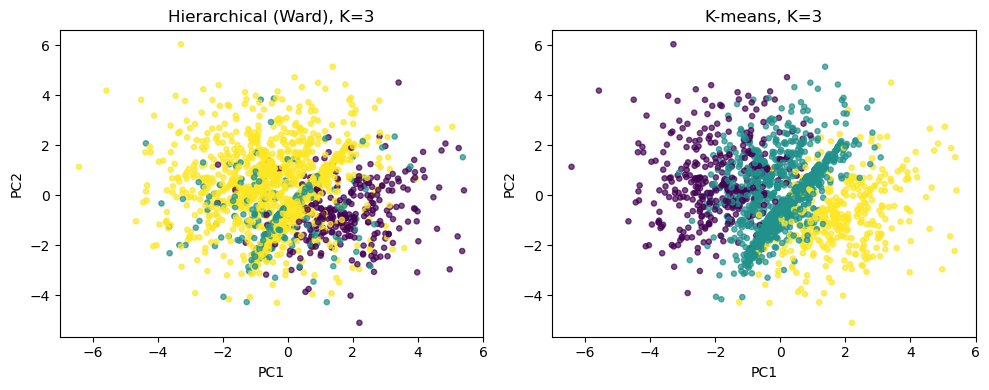

In [31]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(Z[:,0], Z[:,1], c=hc_ward, s=14, alpha=0.7)
plt.title("Hierarchical (Ward), K=3")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.subplot(1,2,2)
plt.scatter(Z[:,0], Z[:,1], c=km, s=14, alpha=0.7)
plt.title("K-means, K=3")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.tight_layout()
plt.show()


K-means shows clearer separation and more balanced clusters than Ward hierarchical clustering in the PCA plot.
Hierarchical clustering forms one large central group, while K-means divides the space more evenly along the main variance direction.
Because PC1-PC2 explain only about 10% of the variance, some overlap remains for both methods.